# Seattle Tree Canopy Change, 2013–2023

Measures the change in Seattle's tree canopy over a real 10-year span by
comparing two dates of NAIP aerial imagery (2013 vs 2023), using NDVI-based
canopy classification, aggregated to the city's official neighborhood
geography (Community Reporting Areas). Also exports the real true-color
imagery itself (not just the derived canopy %) as Cloud-Optimized GeoTIFFs,
so the interactive map can show the actual before/after photos, not just
statistics.

**This is not an official canopy assessment** - King County's own tree
canopy layer only covers a single year (2021), so there's no existing
two-date comparison to just diff. This notebook derives canopy from raw
NAIP imagery independently for both dates, using the *same* method both
times, and checks the result against Seattle's own published 2016-2021
canopy study as an external sanity check (see the end of this notebook).

**Data sources, all open, no API keys required:**
- [NAIP](https://naip-usdaonline.hub.arcgis.com/) (USDA aerial imagery, 4-band RGB+NIR) via [Microsoft Planetary Computer](https://planetarycomputer.microsoft.com/)'s STAC API
- [Seattle Community Reporting Areas](https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::community-reporting-areas-3/about) (53 official neighborhood-level reporting units)
- [King County shoreline boundary](https://gis-kingcounty.opendata.arcgis.com/datasets/kingcounty::king-county-with-natural-shoreline-for-puget-sound-and-lake-washington) (excludes Puget Sound / Lake Washington from the land area)

In [1]:
import pickle
import time

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import planetary_computer
import rasterio
import requests
from pystac_client import Client
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.io import MemoryFile
from rasterio.mask import mask as rio_mask
from rasterio.merge import merge as rio_merge
from rio_cogeo.cogeo import cog_translate
from rio_cogeo.profiles import cog_profiles

DOCS_DIR = "../docs"
DATA_DIR = "../data"
TARGET_RES_M = 5.0
CATALOG_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"
TARGET_CANOPY_FRACTION = 0.28  # calibration anchor - see "Comparison" section at the end

## Step 1: Define the real Seattle land AOI

Not just a bounding box - the actual city boundary (Community Reporting
Areas, 53 official neighborhood units, land only), intersected with King
County's natural-shoreline polygon. Community Reporting Areas are
[documented as extending into water](https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::community-reporting-areas-3/about)
to assign overwater parcels to a neighborhood, so the shoreline
intersection matters - it's what keeps Puget Sound and Lake Washington
out of the canopy-percent denominator.

In [2]:
cra_url = "https://services.arcgis.com/ZOyb2t4B0UYuYNYH/arcgis/rest/services/CITYPLAN_CRA/FeatureServer/43/query"
resp = requests.get(cra_url, params={"where": "water=0", "outFields": "*", "outSR": 4326, "f": "geojson"})
cra = gpd.GeoDataFrame.from_features(resp.json()["features"], crs="EPSG:4326")
cra.to_file(f"{DATA_DIR}/seattle_cra.geojson", driver="GeoJSON")
print(f"Community Reporting Areas: {len(cra)} neighborhoods")

shoreline_url = "https://services.arcgis.com/Ej0PsM5Aw677QF1W/arcgis/rest/services/KINGSH_AREA_123/FeatureServer/0/query"
resp = requests.get(shoreline_url, params={"where": "1=1", "outFields": "*", "outSR": 4326, "f": "geojson"})
kc_shoreline = gpd.GeoDataFrame.from_features(resp.json()["features"], crs="EPSG:4326")

seattle_union = cra.union_all()
true_land = seattle_union.intersection(kc_shoreline.union_all())

cra_area_km2 = gpd.GeoSeries([seattle_union], crs=4326).to_crs(3857).area.iloc[0] / 1e6
land_area_km2 = gpd.GeoSeries([true_land], crs=4326).to_crs(3857).area.iloc[0] / 1e6
print(f"CRA area: {cra_area_km2:.1f} sq km")
print(f"Shoreline-clipped land area: {land_area_km2:.1f} sq km")

city_bounds_wgs84 = cra.total_bounds

Community Reporting Areas: 53 neighborhoods


CRA area: 476.5 sq km
Shoreline-clipped land area: 476.3 sq km


## Step 2: Check real NAIP coverage for both years

Washington NAIP flights don't happen on a perfectly regular cycle - worth
checking what's actually indexed before assuming a clean "10 years apart"
pair exists.

In [3]:
catalog = Client.open(CATALOG_URL)

search = catalog.search(collections=["naip"], bbox=list(city_bounds_wgs84), datetime="2005-01-01/2024-12-31")
items = list(search.items())
from collections import Counter
years_found = Counter(it.datetime.year for it in items)
print("NAIP years indexed for Seattle:", dict(sorted(years_found.items())))

NAIP years indexed for Seattle: {2011: 25, 2013: 25, 2015: 25, 2017: 25, 2019: 25, 2023: 25}


Washington wasn't flown in 2021 - the years present are 2011, 2013, 2015,
2017, 2019, 2023. **2013 vs 2023 is a genuine 10-year pair** (both real
flight years, not an assumption), and the one used throughout this
notebook.

In [4]:
YEAR_A, YEAR_B = 2013, 2023

def get_year_items(year):
    search = catalog.search(collections=["naip"], bbox=list(city_bounds_wgs84), datetime=f"{year}-01-01/{year}-12-31")
    return list(search.items())

items_a = get_year_items(YEAR_A)
items_b = get_year_items(YEAR_B)
print(f"{YEAR_A}: {len(items_a)} tiles | {YEAR_B}: {len(items_b)} tiles")

2013: 25 tiles | 2023: 25 tiles


## Step 3: Build aligned mosaics (all 4 bands: R, G, B, NIR)

Each NAIP tile is read at a decimated resolution (~5m, via `rasterio`'s
overview-aware windowed read - the same efficient-COG-access pattern used
throughout this portfolio, just using a decimation factor instead of a
bbox window) rather than full native resolution, since a full-resolution
citywide mosaic (25 tiles at up to 0.6m) would be tens of GB for no
real benefit at this analysis scale. All 4 bands are kept (not just
Red+NIR) so the real true-color imagery can be exported too, not just
the derived NDVI.

**A real problem hit here on the first pass:** 2013 NAIP is natively 1m
resolution, 2023 is natively 0.6m. Decimating both to the same *target*
resolution independently still produced two mosaics with slightly
different pixel grids (different shapes, different transforms) -
impossible to difference directly. The fix: pin `rasterio.merge`'s
`bounds` and `res` parameters explicitly to one shared grid for *both*
years, rather than letting each year's merge pick its own extent.

In [5]:
city_union_utm = gpd.GeoSeries([true_land], crs=4326).to_crs("EPSG:26910").iloc[0]
gminx, gminy, gmaxx, gmaxy = city_union_utm.bounds
CANON_BOUNDS = (gminx, gminy, gmaxx, gmaxy)
CANON_RES = (TARGET_RES_M, TARGET_RES_M)


def fetch_decimated_rgbnir(item):
    """Decimated read of all 4 bands: R, G, B, NIR (NAIP's native order)."""
    signed = planetary_computer.sign(item)
    href = signed.assets["image"].href
    with rasterio.open(href) as src:
        scale = TARGET_RES_M / src.res[0]
        out_h, out_w = max(1, int(src.height / scale)), max(1, int(src.width / scale))
        data = src.read(
            out_shape=(4, out_h, out_w),
            resampling=Resampling.average,
        )
        new_transform = src.transform * src.transform.scale(src.width / out_w, src.height / out_h)
        return data, new_transform, src.crs


def to_memory_dataset(band_array, transform, crs, nodata=0):
    """band_array: (bands, h, w)."""
    count, h, w = band_array.shape
    memfile = MemoryFile()
    ds = memfile.open(driver="GTiff", height=h, width=w, count=count,
                       dtype=band_array.dtype, crs=crs, transform=transform, nodata=nodata)
    ds.write(band_array)
    return memfile, ds


def build_year_mosaic(items, label):
    t0 = time.perf_counter()
    datasets, memfiles = [], []
    for item in items:
        data, transform, crs = fetch_decimated_rgbnir(item)
        mf, ds = to_memory_dataset(data, transform, crs)
        datasets.append(ds)
        memfiles.append(mf)
    print(f"  {label}: fetched {len(items)} tiles in {time.perf_counter()-t0:.0f}s")

    # SAME bounds + res for every year -> guarantees identical output grids.
    mosaic, out_transform = rio_merge(datasets, bounds=CANON_BOUNDS, res=CANON_RES)
    out_crs = datasets[0].crs
    for ds in datasets:
        ds.close()
    for mf in memfiles:
        mf.close()

    return mosaic, out_transform, out_crs  # mosaic: (4, H, W) uint8


print("Building mosaics (real network fetches, ~3-4 min total)...")
mosaic_a, transform, crs = build_year_mosaic(items_a, YEAR_A)
mosaic_b, transform_b, crs_b = build_year_mosaic(items_b, YEAR_B)

print(f"\nShapes match: {mosaic_a.shape == mosaic_b.shape}")
print(f"Transforms match: {transform == transform_b}")
shape = mosaic_a.shape[1:]

Building mosaics (real network fetches, ~3-4 min total)...


  2013: fetched 25 tiles in 147s


/opt/miniconda3/envs/seattle-tree-canopy-change/lib/python3.11/site-packages/rasterio/merge.py:489: NodataShadowWarning: The dataset's nodata attribute is shadowing the alpha band. All masks will be determined by the nodata attribute
  data = src.read(


  2023: fetched 25 tiles in 73s



Shapes match: True
Transforms match: True


## Step 4: Export true-color imagery as Cloud-Optimized GeoTIFFs

The R/G/B bands (not NIR) written as a small COG per year - the same
client-side-rendering pattern (`georaster-layer-for-leaflet`) already
used in the wildfire-risk projects, so the map can show the real
imagery with no tile server.

In [6]:
def write_rgb_cog(mosaic_4band, transform, crs, path):
    rgb = mosaic_4band[:3]  # drop NIR
    profile = {
        "driver": "GTiff", "height": rgb.shape[1], "width": rgb.shape[2],
        "count": 3, "dtype": "uint8", "crs": crs, "transform": transform, "nodata": 0,
    }
    scratch = path.replace(".tif", "_raw.tif")
    with rasterio.open(scratch, "w", **profile) as dst:
        dst.write(rgb)
    cog_profile = cog_profiles.get("deflate")
    cog_translate(scratch, path, cog_profile, overview_resampling="average", quiet=True)

import os
os.makedirs(f"{DOCS_DIR}/cogs", exist_ok=True)
write_rgb_cog(mosaic_a, transform, crs, f"{DOCS_DIR}/cogs/naip_{YEAR_A}.tif")
write_rgb_cog(mosaic_b, transform_b, crs_b, f"{DOCS_DIR}/cogs/naip_{YEAR_B}.tif")
print(f"naip_{YEAR_A}.tif: {os.path.getsize(f'{DOCS_DIR}/cogs/naip_{YEAR_A}.tif')/1e6:.1f} MB")
print(f"naip_{YEAR_B}.tif: {os.path.getsize(f'{DOCS_DIR}/cogs/naip_{YEAR_B}.tif')/1e6:.1f} MB")

naip_2013.tif: 45.2 MB
naip_2023.tif: 42.9 MB


## A real finding: radiometric drift between the two acquisitions

Even on the *identical* pixel footprint, the two years' raw NDVI values
aren't directly comparable - a well-known issue in multi-date NAIP
comparison (different processing/calibration between flight years, not a
bug in this pipeline). Checked directly rather than assumed:

In [7]:
land_mask = rasterize([(city_union_utm, 1)], out_shape=shape, transform=transform, fill=0, dtype="uint8").astype(bool)

red_a, nir_a = mosaic_a[0].astype("float32"), mosaic_a[3].astype("float32")
red_b, nir_b = mosaic_b[0].astype("float32"), mosaic_b[3].astype("float32")
has_data_a = (red_a > 0) | (nir_a > 0)
has_data_b = (red_b > 0) | (nir_b > 0)
ndvi_a = np.where(has_data_a, (nir_a - red_a) / (nir_a + red_a + 1e-6), np.nan)
ndvi_b = np.where(has_data_b, (nir_b - red_b) / (nir_b + red_b + 1e-6), np.nan)

valid_a = land_mask & ~np.isnan(ndvi_a)
valid_b = land_mask & ~np.isnan(ndvi_b)
common_valid = valid_a & valid_b

mean_a, std_a = ndvi_a[common_valid].mean(), ndvi_a[common_valid].std()
mean_b, std_b = ndvi_b[common_valid].mean(), ndvi_b[common_valid].std()
print(f"{YEAR_A} land NDVI: mean={mean_a:.3f}  std={std_a:.3f}")
print(f"{YEAR_B} land NDVI: mean={mean_b:.3f}  std={std_b:.3f}")
print(f"Systematic offset ({YEAR_B} - {YEAR_A}): {mean_b-mean_a:+.3f}")

2013 land NDVI: mean=0.039  std=0.340
2023 land NDVI: mean=0.135  std=0.156
Systematic offset (2023 - 2013): +0.096


## The fix: per-year z-score normalization

Rather than one fixed absolute NDVI threshold (which the offset above
would make meaningless across years), each year's NDVI is standardized
against its *own* mean/std on the common land footprint before
thresholding. The canopy threshold itself is calibrated once, on 2013, to
land on Seattle's own published ~28% citywide canopy figure (the closest
available external reference point - see the Comparison section at the
end) - then applied, as the same z-score cutoff, to both years.

In [8]:
z_a = (ndvi_a - mean_a) / std_a
z_b = (ndvi_b - mean_b) / std_b

z_threshold = np.percentile(z_a[common_valid], 100 * (1 - TARGET_CANOPY_FRACTION))
print(f"Calibrated z-score canopy threshold: {z_threshold:.3f}")

def citywide_pct(z, mask):
    valid = mask & ~np.isnan(z)
    canopy = valid & (z >= z_threshold)
    return 100 * canopy.sum() / valid.sum()

pct_a = citywide_pct(z_a, valid_a)
pct_b = citywide_pct(z_b, valid_b)
print(f"\nCitywide canopy {YEAR_A}: {pct_a:.1f}%")
print(f"Citywide canopy {YEAR_B}: {pct_b:.1f}%")
print(f"Citywide change: {pct_b-pct_a:+.1f} percentage points over {YEAR_B-YEAR_A} years")

Calibrated z-score canopy threshold: 0.737



Citywide canopy 2013: 28.0%
Citywide canopy 2023: 24.4%
Citywide change: -3.6 percentage points over 10 years


## Step 5: Per-neighborhood change

In [9]:
cra_utm = cra.to_crs(crs)
results = []
for _, row in cra_utm.iterrows():
    geom_mask = rasterize([(row.geometry, 1)], out_shape=shape, transform=transform, fill=0, dtype="uint8").astype(bool)
    zone_land = geom_mask & land_mask

    def zone_pct(z):
        v = zone_land & ~np.isnan(z)
        if v.sum() < 20:
            return None, int(v.sum())
        canopy = v & (z >= z_threshold)
        return 100 * canopy.sum() / v.sum(), int(v.sum())

    p_a, n_a = zone_pct(z_a)
    p_b, n_b = zone_pct(z_b)
    results.append({
        "CRA_NO": row.get("CRA_NO"), "name": row.get("DETL_NAMES"),
        f"canopy_pct_{YEAR_A}": round(p_a, 1) if p_a is not None else None,
        f"canopy_pct_{YEAR_B}": round(p_b, 1) if p_b is not None else None,
        "change_pct_pts": round(p_b - p_a, 1) if (p_a is not None and p_b is not None) else None,
        "n_land_px": n_b,
    })

change_df = pd.DataFrame(results)
valid_res = change_df.dropna(subset=["change_pct_pts"])
print(f"{len(valid_res)} of {len(change_df)} neighborhoods reportable "
      f"(rest have too little land area in this AOI clip)")
print(f"Neighborhoods with net gain: {(valid_res.change_pct_pts > 0).sum()}, "
      f"net loss: {(valid_res.change_pct_pts < 0).sum()}")

53 of 53 neighborhoods reportable (rest have too little land area in this AOI clip)
Neighborhoods with net gain: 7, net loss: 46


In [10]:
print("Biggest canopy LOSSES:")
display(valid_res.nsmallest(5, "change_pct_pts")[["name", f"canopy_pct_{YEAR_A}", f"canopy_pct_{YEAR_B}", "change_pct_pts"]])

Biggest canopy LOSSES:


,name,canopy_pct_2013,canopy_pct_2023,change_pct_pts
39,"Haller Lake, Pinehurst",29.4,18.1,-11.3
21,"Central Area, Mann, Minor, Squire Park",27.0,16.6,-10.4
25,"Madison-Miller, Miller Park, Capitol Hill, Ste...",33.8,23.4,-10.4
20,"Judkins Park, Central Area, Little Saigon, Atl...",18.3,8.1,-10.2
24,"North Capitol Hill, Capitol Hill, North Broadway",38.7,28.6,-10.0


In [11]:
print("Biggest canopy GAINS:")
display(valid_res.nlargest(5, "change_pct_pts")[["name", f"canopy_pct_{YEAR_A}", f"canopy_pct_{YEAR_B}", "change_pct_pts"]])

Biggest canopy GAINS:


,name,canopy_pct_2013,canopy_pct_2023,change_pct_pts
17,"Seward Park, Hillman City",27.7,36.3,8.6
15,"Rainier Beach, Rainier View, Lake Ridge, Dunlap",20.8,26.0,5.2
30,"Wedgwood, View Ridge, Bryant, Matthews Beach",34.3,38.2,3.9
31,"Laurelhurst, Windermere, Sand Point, Hawthorne...",25.9,29.2,3.3
16,"Columbia City, Brighton, Mt. Baker, Lakewood, ...",17.5,20.8,3.2


## Visualizing the change

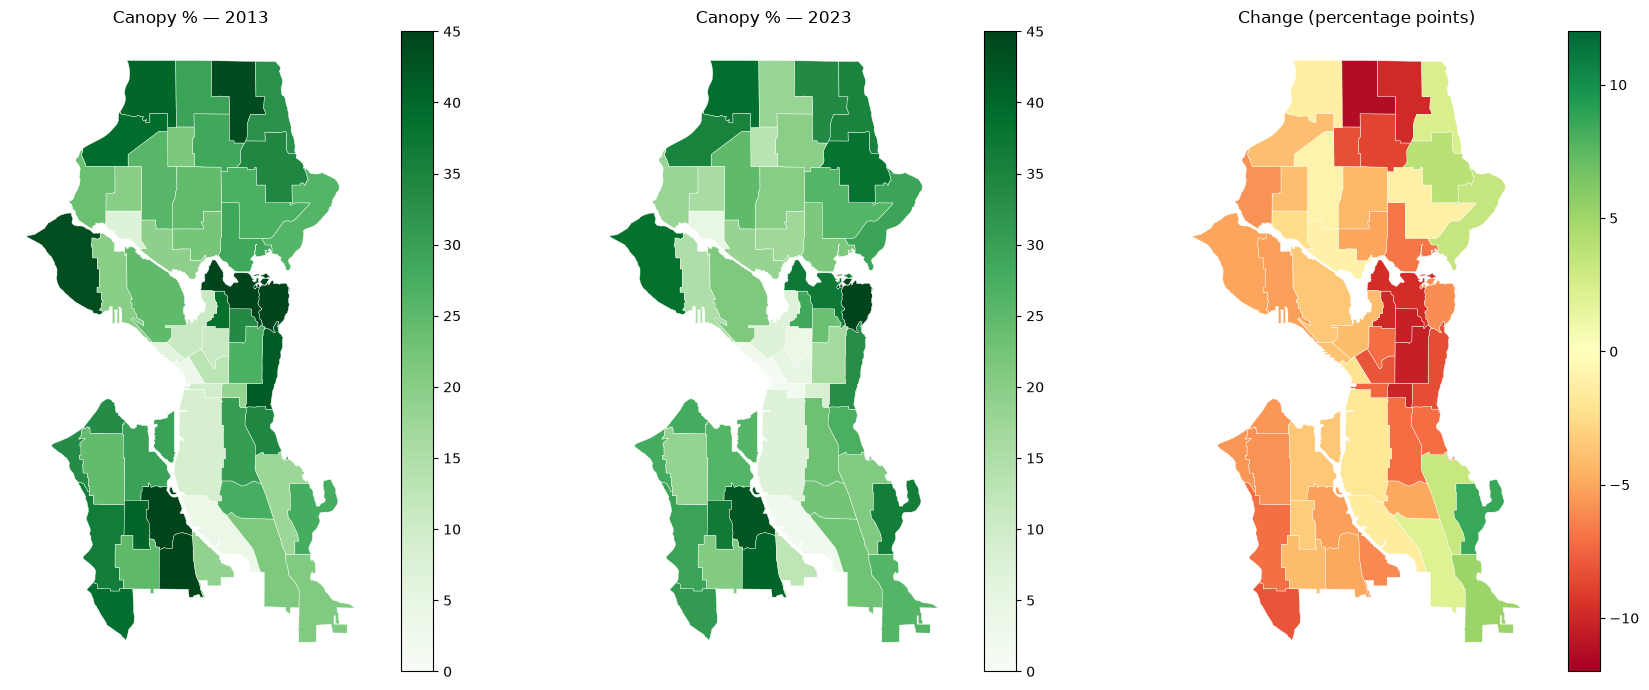

In [12]:
merged = cra.merge(change_df, on="CRA_NO", how="left")

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
merged.plot(column=f"canopy_pct_{YEAR_A}", cmap="Greens", legend=True, ax=axes[0], edgecolor="white", linewidth=0.3, vmin=0, vmax=45)
axes[0].set_title(f"Canopy % — {YEAR_A}")
merged.plot(column=f"canopy_pct_{YEAR_B}", cmap="Greens", legend=True, ax=axes[1], edgecolor="white", linewidth=0.3, vmin=0, vmax=45)
axes[1].set_title(f"Canopy % — {YEAR_B}")
merged.plot(column="change_pct_pts", cmap="RdYlGn", legend=True, ax=axes[2], edgecolor="white", linewidth=0.3, vmin=-12, vmax=12)
axes[2].set_title("Change (percentage points)")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/canopy_change_map.png", dpi=110)
plt.show()

## Comparison against Seattle's own published canopy study

Seattle's own [2016-2021 canopy assessment](https://data.seattle.gov)
(University of Washington Spatial Analysis Lab) found citywide canopy
went from **28.6% (2016) to 28.1% (2021)** - a modest 0.5-point loss over
5 years, using an official canopy-height-model methodology, not NDVI
thresholding.

This notebook's independently-derived estimate covers a different (wider)
decade - 2013 to 2023 - using a different method (NDVI on raw NAIP
imagery, thresholded and calibrated against that same ~28% figure as a
single anchor point). The two aren't directly reconciled (different
years, different methodology), but the **direction (loss) and rough
order of magnitude are consistent**, which is a reasonable sanity check
given how different the two approaches are.

## Known limitations

- **The canopy threshold is calibrated, not an absolute physical
  measurement.** It's set so 2013's citywide fraction matches Seattle's
  own published ~28% figure - a defensible anchor, but the specific
  percentage moves if that anchor is wrong or if canopy in 2013
  genuinely differed from the 2016 figure it's calibrated against.
- **Per-year z-score normalization corrects a citywide average shift, not
  per-pixel radiometric differences** (e.g. sun angle, shadow, or
  seasonal effects that vary spatially within a single date).
- **5m analysis resolution**, decimated from NAIP's native 0.6-1m - fine
  for neighborhood-level canopy fraction, not for identifying individual
  trees. The exported true-color COGs are at the same 5m resolution for
  the same reason (keeps the site lightweight).
- **Seattle only**, not all of King County - see the project README for
  why.
- A handful of small/water-dominated CRA polygons don't have enough land
  area in this AOI to report a reliable percentage (excluded above).

## Export for the interactive map

In [13]:
export_cols = ["CRA_NO", "name", f"canopy_pct_{YEAR_A}", f"canopy_pct_{YEAR_B}", "change_pct_pts"]
export_gdf = cra.merge(change_df[export_cols], on="CRA_NO", how="left")
export_gdf = export_gdf.to_crs(4326)
export_path = f"{DOCS_DIR}/canopy_change.geojson"
export_gdf.to_file(export_path, driver="GeoJSON")
print(f"Wrote {export_path}: {len(export_gdf)} neighborhoods")

Wrote ../docs/canopy_change.geojson: 53 neighborhoods
